In [47]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os

## Loading in model data

In [48]:
df = xr.open_dataset("SC_1995-2014.nc", engine="netcdf4")
var_snowd = df["SNOW_DEPTH"]
var_snowd

C:\Users\madel\AppData\Local\Temp\ipykernel_30028\4173073790.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset("SC_1995-2014.nc", engine="netcdf4")


<xarray.DataArray 'SNOW_DEPTH' (time: 7300, lndgrid: 1)> Size: 29kB
[7300 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      snow height of snow covered area
    units:          m
    cell_methods:   time: mean
    landunit_mask:  unknown

## Observational Plots

NOTE: Currently files need to be in opposite time order from top to bottom for the combination code to work. This is because sorting by datetime in pandas is being weird and i dont wana figure it out rn

In [49]:
def obs_data_parse(file):
    obs = pd.read_csv(
    f"{file}",   # just change the extension
    comment="#",
    sep=r"\s+|,|\t",
    parse_dates=["Timestamp"],
    engine="python"
    )
    obs.rename(columns={"Timestamp": "time", "Value": "obs_depth"}, inplace=True)
    return obs

In [50]:
# Input ypur path to all observational values
# Makes a simple list for now but could definitely be a dictionary later
directory_path = "SC_obs/snow_depth"
observe = []

for filename in os.listdir(directory_path):
    # Join the directory path and the filename to get the full file path
    full_path = os.path.join(directory_path, filename)
    # Check if it is a file (not a directory)
    if os.path.isfile(full_path):
        df = obs_data_parse(full_path)
        observe.append(df)


In [51]:
observe[0]

,time,obs_depth
0,2013-04-30 06:00:00+00:00,0.9
1,2013-04-30 10:00:00+00:00,8.5
2,2013-04-30 14:00:00+00:00,7.9
3,2013-04-30 18:00:00+00:00,25.2
4,2013-04-30 22:00:00+00:00,25.6
...,...,...
916,2013-09-29 22:00:00+00:00,26.5
917,2013-09-30 02:00:00+00:00,-5.1
918,2013-09-30 06:00:00+00:00,34.0
919,2013-09-30 10:00:00+00:00,-5.2


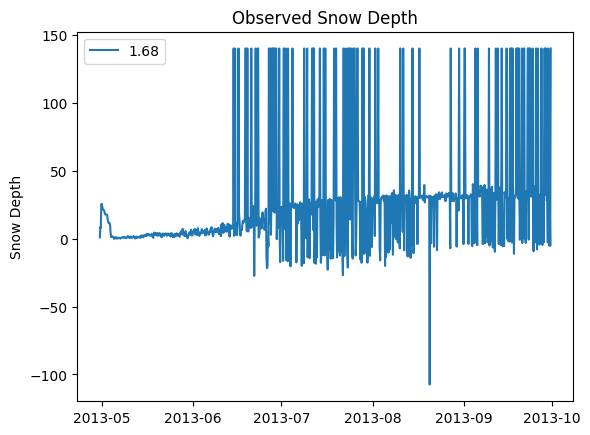

In [52]:
for data in observe:  
    plt.plot(data["time"], data["obs_depth"])
#plt.plot(obs2["time"], obs2["obs_depth"])
plt.ylabel("Snow Depth")
plt.title("Observed Snow Depth")
plt.legend(['1.68', '1.47'])
plt.show()

Seems like the 1.68 data has negative values for some reason. Both datasets also max out at their respective sensor location, so 1.68 and 1.47.

## Combining data

first we check the units of the data.

In [53]:
var_snowd

<xarray.DataArray 'SNOW_DEPTH' (time: 7300, lndgrid: 1)> Size: 29kB
[7300 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      snow height of snow covered area
    units:          m
    cell_methods:   time: mean
    landunit_mask:  unknown

## Insert any conversions or other data manipulation

Its in meters so I'm going to change the observational data to meters to match. For now, I'll also be removing any negative values.

In [54]:
obs_clean = []
for n in observe:
    n["obs_depth"] = n["obs_depth"]/1000
    #obs1_cleaned = obs1[obs1["obs_depth"] >= 0]
    n = n[n["obs_depth"] >= 0]
    n["time"] = pd.to_datetime(n["time"])
    obs_clean.append(n)
    

print(obs_clean[0])


                         time  obs_depth
0   2013-04-30 06:00:00+00:00     0.0009
1   2013-04-30 10:00:00+00:00     0.0085
2   2013-04-30 14:00:00+00:00     0.0079
3   2013-04-30 18:00:00+00:00     0.0252
4   2013-04-30 22:00:00+00:00     0.0256
..                        ...        ...
913 2013-09-29 10:00:00+00:00     0.0316
915 2013-09-29 18:00:00+00:00     0.1400
916 2013-09-29 22:00:00+00:00     0.0265
918 2013-09-30 06:00:00+00:00     0.0340
920 2013-09-30 14:00:00+00:00     0.1400

[789 rows x 2 columns]


plot to check

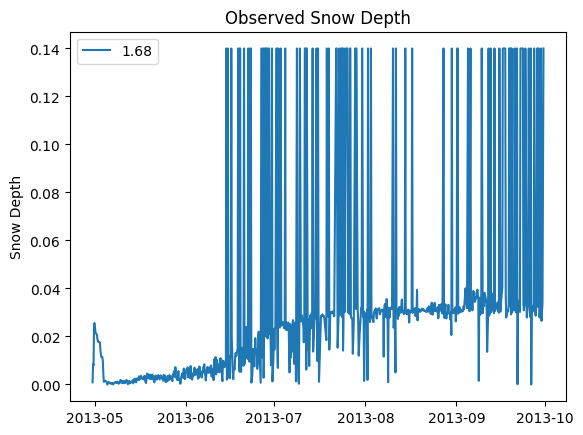

In [55]:
for data in obs_clean:  
    plt.plot(data["time"], data["obs_depth"])
plt.ylabel("Snow Depth")
plt.title("Observed Snow Depth")
plt.legend(['1.68', '1.47'])
plt.show()

looks good so let's plot all the data

In [56]:
sim = var_snowd.copy()
sim['time'] = sim.indexes['time'].to_datetimeindex()


C:\Users\madel\AppData\Local\Temp\ipykernel_30028\891719653.py:2: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  sim['time'] = sim.indexes['time'].to_datetimeindex()
C:\Users\madel\AppData\Local\Temp\ipykernel_30028\891719653.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  sim['time'] = sim.indexes['time'].to_datetimeindex()


In [57]:
obs_concat = pd.concat(obs_clean, ignore_index=True, sort=True)
print(obs_concat)

     obs_depth                      time
0       0.0009 2013-04-30 06:00:00+00:00
1       0.0085 2013-04-30 10:00:00+00:00
2       0.0079 2013-04-30 14:00:00+00:00
3       0.0252 2013-04-30 18:00:00+00:00
4       0.0256 2013-04-30 22:00:00+00:00
..         ...                       ...
784     0.0316 2013-09-29 10:00:00+00:00
785     0.1400 2013-09-29 18:00:00+00:00
786     0.0265 2013-09-29 22:00:00+00:00
787     0.0340 2013-09-30 06:00:00+00:00
788     0.1400 2013-09-30 14:00:00+00:00

[789 rows x 2 columns]


In [58]:
with open("era5_west/data_0.nc", "rb") as f:
    print(f.read(4))
with open("era5_west_2/data_0.nc", "rb") as f:
    print(f.read(4))

b'\x89HDF'
b'\x89HDF'


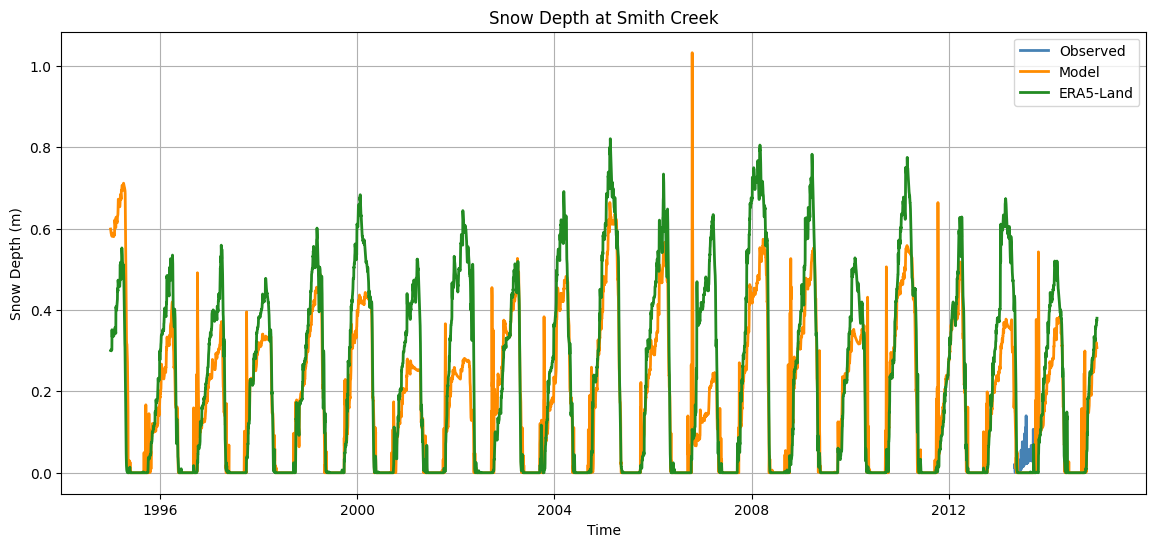

In [59]:
import glob

# Load and combine the two ERA5 files
files = ["era5_west/data_0.nc", "era5_west_2/data_0.nc"]
era5 = xr.open_mfdataset(files, combine="by_coords")

# Extract Smith Creek
era5_sc = era5["sde"].sel(
    latitude=63.1534,
    longitude=-123.2522 % 360,
    method="nearest"
)

# Convert pandas → xarray
obs = obs_concat.set_index("time").to_xarray()
obs_daily = obs.resample(time="1D").mean()

plt.figure(figsize=(14,6))
plt.plot(
    obs_daily["time"].values,
    obs_daily["obs_depth"].values,
    label="Observed",
    color='steelblue',
    linewidth=2
)
plt.plot(
    sim["time"].values,
    sim.values,
    label="Model",
    color='darkorange',
    linewidth=2
)
plt.plot(
    era5_sc["valid_time"].values,
    era5_sc.values,
    label="ERA5-Land",
    color='forestgreen',
    linewidth=2
)
plt.xlabel("Time")
plt.ylabel("Snow Depth (m)")
plt.title("Snow Depth at Smith Creek")
plt.grid(True)
plt.legend()
plt.savefig("0_final_images/SC_snow_depth.png")
plt.show()